# Bagian 1 — Banking Transaction Analysis
## CRISP-DM Framework

## 1. Business Understanding
**Problem Statement:**
The bank wants to better understand its customers by segmenting them based on
their transaction behavior. Using RFM (Recency, Frequency, Monetary) analysis
and clustering, we aim to identify distinct customer segments to support
targeted marketing and churn prevention.

**Business Value:** Personalized offers, reduced churn, improved customer retention.

## 2. Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
df_india = pd.read_csv('bank_customer_transactions.csv')
df_foreign = pd.read_csv('foreign_customer_dataset.csv')

print('India shape:', df_india.shape)
print('Foreign shape:', df_foreign.shape)
df_india.head()

India shape: (1048567, 9)
Foreign shape: (3584, 11)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [3]:
# Check data types and missing values
print(df_india.info())
print('\nMissing values (India):')
print(df_india.isnull().sum())

print('\nMissing values (Foreign):')
print(df_foreign.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  str    
 1   CustomerID               1048567 non-null  str    
 2   CustomerDOB              1045170 non-null  str    
 3   CustGender               1047467 non-null  str    
 4   CustLocation             1048416 non-null  str    
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  str    
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 72.0 MB
None

Missing values (India):
TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
Tr

In [4]:
# Basic statistics
df_india.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


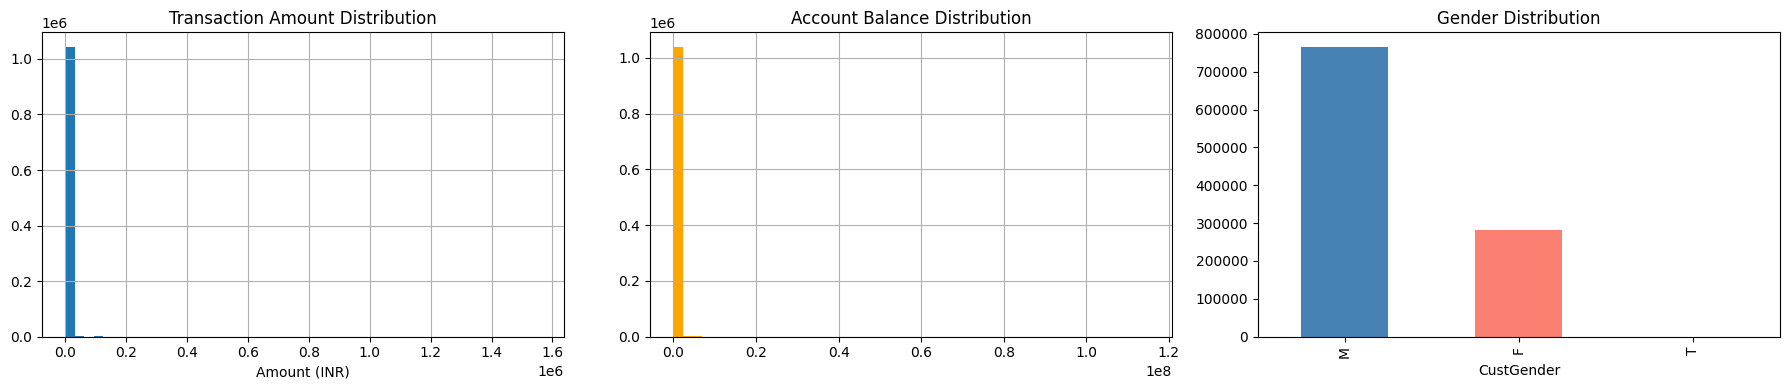

In [5]:
# Visualize key distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Transaction Amount distribution
df_india['TransactionAmount (INR)'].hist(bins=50, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (INR)')

# Account Balance distribution
df_india['CustAccountBalance'].hist(bins=50, ax=axes[1], color='orange')
axes[1].set_title('Account Balance Distribution')

# Gender distribution
df_india['CustGender'].value_counts().plot(kind='bar', ax=axes[2], color=['steelblue','salmon'])
axes[2].set_title('Gender Distribution')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150)  # save for report screenshot
plt.show()

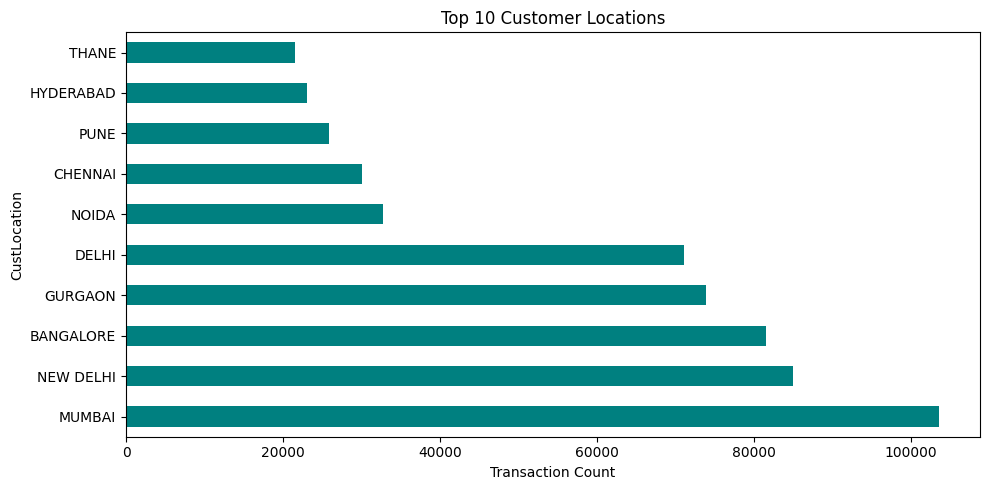

In [6]:
# Top 10 customer locations
top_locations = df_india['CustLocation'].value_counts().head(10)
top_locations.plot(kind='barh', figsize=(10,5), color='teal')
plt.title('Top 10 Customer Locations')
plt.xlabel('Transaction Count')
plt.tight_layout()
plt.savefig('top_locations.png', dpi=150)
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [7]:
# --- Standardize and merge both datasets ---

# Drop extra index column in foreign dataset if exists
if df_foreign.columns[0] == 'Unnamed: 0':
    df_foreign = df_foreign.drop(columns=df_foreign.columns[0])

# Drop 'Age' from foreign since we'll recompute it
if 'Age' in df_foreign.columns:
    df_foreign = df_foreign.drop(columns=['Age'])

# Combine datasets
df = pd.concat([df_india, df_foreign], ignore_index=True)
print('Combined shape:', df.shape)

Combined shape: (1052151, 9)


In [8]:
# --- Parse Dates ---
# TransactionDate has different formats in both datasets — handle with errors='coerce'
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, errors='coerce')
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], dayfirst=True, errors='coerce')

print('Date parsing issues:', df['TransactionDate'].isnull().sum())
print('DOB parsing issues:', df['CustomerDOB'].isnull().sum())

Date parsing issues: 0
DOB parsing issues: 3397


In [9]:
# --- Feature Engineering ---

# 1. Age from DOB
reference_date = pd.Timestamp('2016-12-31')  # approximate end of dataset period
df['Age'] = ((reference_date - df['CustomerDOB']).dt.days / 365).round(1)

# 2. Is Weekend
df['is_weekend'] = df['TransactionDate'].dt.dayofweek.isin([5, 6]).astype(int)

# 3. Transaction Hour (TransactionTime might be HHMMSS integer or string)
df['TransactionTime'] = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionHour'] = df['TransactionTime'].str[:2].astype(int)

# 4. Transaction Month & Day of Week
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()

print(df[['Age', 'is_weekend', 'TransactionHour', 'TransactionMonth']].head())

    Age  is_weekend  TransactionHour  TransactionMonth
0  23.0           0               14                 8
1 -40.3           0               14                 8
2  20.1           0               14                 8
3 -56.7           0               14                 8
4  28.8           0               18                 8


In [10]:
# --- RFM Feature Engineering (per customer) ---

snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('TransactionDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('TransactionID',   'count'),
    Monetary  = ('TransactionAmount (INR)', 'sum')
).reset_index()

print(rfm.describe())
rfm.head()

             Recency      Frequency      Monetary
count  884265.000000  884265.000000  8.842650e+05
mean      105.262487       1.189859  1.887416e+03
std        15.342918       0.456811  7.420296e+03
min         1.000000       1.000000  0.000000e+00
25%        93.000000       1.000000  2.000000e+02
50%       105.000000       1.000000  5.380000e+02
75%       118.000000       1.000000  1.501000e+03
max       131.000000       7.000000  1.560035e+06


,CustomerID,Recency,Frequency,Monetary
0,C1010011,75,2,5106.0
1,C1010012,118,1,1499.0
2,C1010014,125,2,1455.0
3,C1010018,86,1,30.0
4,C1010024,114,1,5000.0


In [12]:
# --- Handle Outliers in RFM using log transform ---
from numpy import log1p

rfm_log = rfm.copy()
rfm_log['Recency']   = log1p(rfm['Recency'])
rfm_log['Frequency'] = log1p(rfm['Frequency'])
rfm_log['Monetary']  = log1p(rfm['Monetary'])

# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

## 4. Data Modelling — KMeans Clustering (Unsupervised)

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

# Elbow method to find optimal k
inertias = []
silhouettes = []
K_range = range(2, 3)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

KeyboardInterrupt: 

In [ ]:
# --- Train Final Model with Best k ---
BEST_K = 4  # change based on elbow/silhouette results

start = time.time()
kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
kmeans_final.fit(rfm_scaled)
end = time.time()

print(f'Training time: {end - start:.4f} seconds')

rfm['Cluster'] = kmeans_final.labels_
print('Silhouette Score:', silhouette_score(rfm_scaled, kmeans_final.labels_))

## 5. Evaluation & Interpretation

In [ ]:
# Cluster Profiles
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_profile['Count'] = rfm.groupby('Cluster')['CustomerID'].count()
print(cluster_profile)

# Visualize cluster profiles
cluster_profile[['Recency', 'Frequency', 'Monetary']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2'
)
plt.title('Cluster RFM Profiles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

In [ ]:
# 2D Scatter: Frequency vs Monetary colored by cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rfm['Frequency'], rfm['Monetary'],
    c=rfm['Cluster'], cmap='Set1', alpha=0.6, edgecolors='k', linewidths=0.3
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Frequency')
plt.ylabel('Monetary (INR)')
plt.title('Customer Segments by Frequency vs Monetary')
plt.savefig('cluster_scatter.png', dpi=150)
plt.show()

# Label clusters with business meaning (update after reviewing profile)
cluster_labels = {
    0: 'Champions',
    1: 'At Risk',
    2: 'New Customers',
    3: 'Hibernating'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print(rfm['Segment'].value_counts())

## 6. Limitations & Lesson Learned

- **Limitations:** No labeled data to validate clusters; date format inconsistency between datasets required careful handling; RFM doesn't capture transaction type or context.
- **Challenges:** Merging datasets with different date formats; handling outliers in monetary values.
- **Lesson Learned:** Log transformation is important before clustering when monetary values are heavily skewed. Silhouette score provides a more reliable measure of cluster quality than inertia alone.